# Polymarket Political Markets — EDA
**20 highest-volume closed binary political markets**  
Daily YES-token price candles + up to 2,000 most-recent historical fills per market.

---

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.cm as cm
from matplotlib.colors import to_hex
from pathlib import Path

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({'figure.dpi':110,'axes.titlesize':10,'axes.labelsize':9,'xtick.labelsize':7,'ytick.labelsize':7,'legend.fontsize':7})
EDA = Path('.')

## 1. Load data

In [2]:
markets = pl.read_csv(EDA / 'markets.csv')
print(f'{len(markets)} markets')
markets[['slug','question','resolution','volume_usdc','start_date','end_date']]

20 markets


slug,question,resolution,volume_usdc,start_date,end_date
str,str,str,f64,str,str
"""will-donald-trump-win-the-2024…","""Will Donald Trump win the 2024…","""Yes""",1.5315e9,"""2024-01-04""","""2024-11-05"""
"""will-kamala-harris-win-the-202…","""Will Kamala Harris win the 202…","""No""",1.0370e9,"""2024-01-04""","""2024-11-04"""
"""will-donald-trump-be-inaugurat…","""Will Donald Trump be inaugurat…","""Yes""",4.0041e8,"""2024-11-01""","""2025-01-20"""
"""will-nicolae-ciuca-win-the-202…","""Will Nicolae Ciucă win the 202…","""No""",3.2651e8,"""2024-11-08""","""2024-12-08"""
"""will-any-other-republican-poli…","""Will any other Republican Poli…","""No""",2.4166e8,"""2024-01-06""","""2024-11-05"""
…,…,…,…,…,…
"""will-lee-jae-myung-be-elected-…","""Will Lee Jae-myung be elected …","""Yes""",8.8036e7,"""2025-04-04""","""2025-06-03"""
"""romania-presidential-election-…","""Will Hunor Kelemen win the Rom…","""No""",8.0897e7,"""2025-01-17""","""2025-12-31"""
"""will-trump-launch-a-coin-befor…","""Will Trump launch a coin befor…","""Yes""",7.6899e7,"""2024-06-18""","""2024-11-04"""


In [3]:
PRICE_SCHEMA  = {'timestamp': pl.Int64, 'price': pl.Float64}
TRADES_SCHEMA = {'timestamp': pl.Int64, 'price': pl.Float64, 'size': pl.Float64}

def load_ph(slug):
    p = EDA / slug / 'price_history.csv'
    if not p.exists(): return None
    return (pl.read_csv(p, schema_overrides=PRICE_SCHEMA)
            .with_columns((pl.col('timestamp') * 1_000_000).cast(pl.Datetime('us')).alias('date')))

def load_tr(slug):
    p = EDA / slug / 'trades.csv'
    if not p.exists(): return None
    return (pl.read_csv(p, schema_overrides=TRADES_SCHEMA, ignore_errors=True)
            .with_columns((pl.col('timestamp') * 1_000_000).cast(pl.Datetime('us')).alias('date')))

ph_frames, tr_frames = [], []
for row in markets.iter_rows(named=True):
    slug = row['slug']
    ph = load_ph(slug)
    if ph is not None:
        ph_frames.append(ph.with_columns([pl.lit(slug).alias('slug'),pl.lit(row['resolution']).alias('resolution'),pl.lit(row['question']).alias('question'),pl.lit(float(row['volume_usdc'] or 0)).alias('volume_usdc')]))
    tr = load_tr(slug)
    if tr is not None:
        tr_frames.append(tr.with_columns([pl.lit(slug).alias('market_slug'),pl.lit(row['question']).alias('question'),pl.lit(row['resolution']).alias('resolution')]))

price_history = pl.concat(ph_frames)
trades_all    = pl.concat(tr_frames)

slug_to_short = {row['slug']: row['question'].replace('Will ','').replace('will ','').split(' win')[0].split(' be ')[0][:18] for row in markets.iter_rows(named=True)}

print(f'Price history : {len(price_history):,} daily candles')
print(f'Trades        : {len(trades_all):,} fills')
print(f'Trade size    : median=${trades_all["size"].median():.2f}  max=${trades_all["size"].max():,.2f}')

Price history : 3,888 daily candles
Trades        : 40,000 fills
Trade size    : median=$200.00  max=$3,735,309.91


In [4]:
# Hex-string colour maps — no numpy array truth-value issues
def make_hex_colors(slugs, cmap_name):
    if not slugs: return {}
    cmap = cm.get_cmap(cmap_name)
    return {slug: to_hex(cmap(float(v))) for slug, v in zip(slugs, np.linspace(0.45, 0.9, len(slugs)))}

yes_slugs  = markets.filter(pl.col('resolution') == 'Yes')['slug'].to_list()
no_slugs   = markets.filter(pl.col('resolution') == 'No' )['slug'].to_list()
color_map  = {**make_hex_colors(yes_slugs, 'Greens'), **make_hex_colors(no_slugs, 'Reds')}
print('Colour map built:', len(color_map), 'markets')

Colour map built: 20 markets


## 2. All markets — YES price over calendar time
Green = resolved **Yes**, Red = resolved **No**.

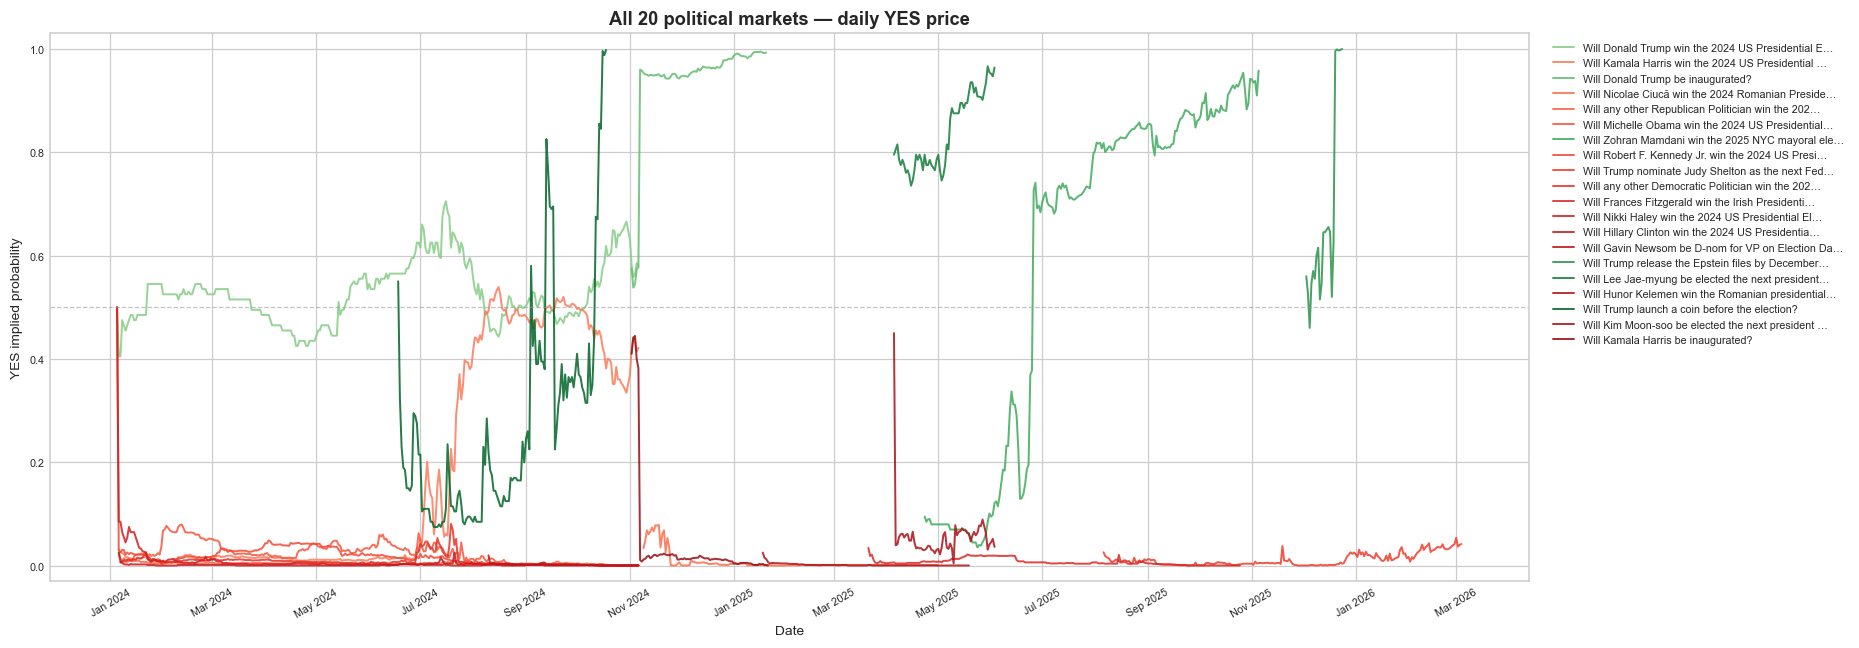

In [5]:
fig, ax = plt.subplots(figsize=(17, 6))
for row in markets.iter_rows(named=True):
    slug   = row['slug']
    df     = price_history.filter(pl.col('slug') == slug).sort('date')
    dates  = df['date'].to_list()
    prices = df['price'].to_list()
    label  = row['question'][:48] + '…' if len(row['question']) > 48 else row['question']
    ax.plot(dates, prices, color=color_map[slug], linewidth=1.3, alpha=0.85, label=label)
ax.axhline(0.5, color='#999', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_ylim(-0.03, 1.03)
ax.set_ylabel('YES implied probability')
ax.set_xlabel('Date')
ax.set_title('All 20 political markets — daily YES price', fontweight='bold', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1, framealpha=0.8)
plt.tight_layout()
plt.show()

## 3. Price velocity — dy/dx
Daily rate of change. Spikes = news events or large coordinated order flow.

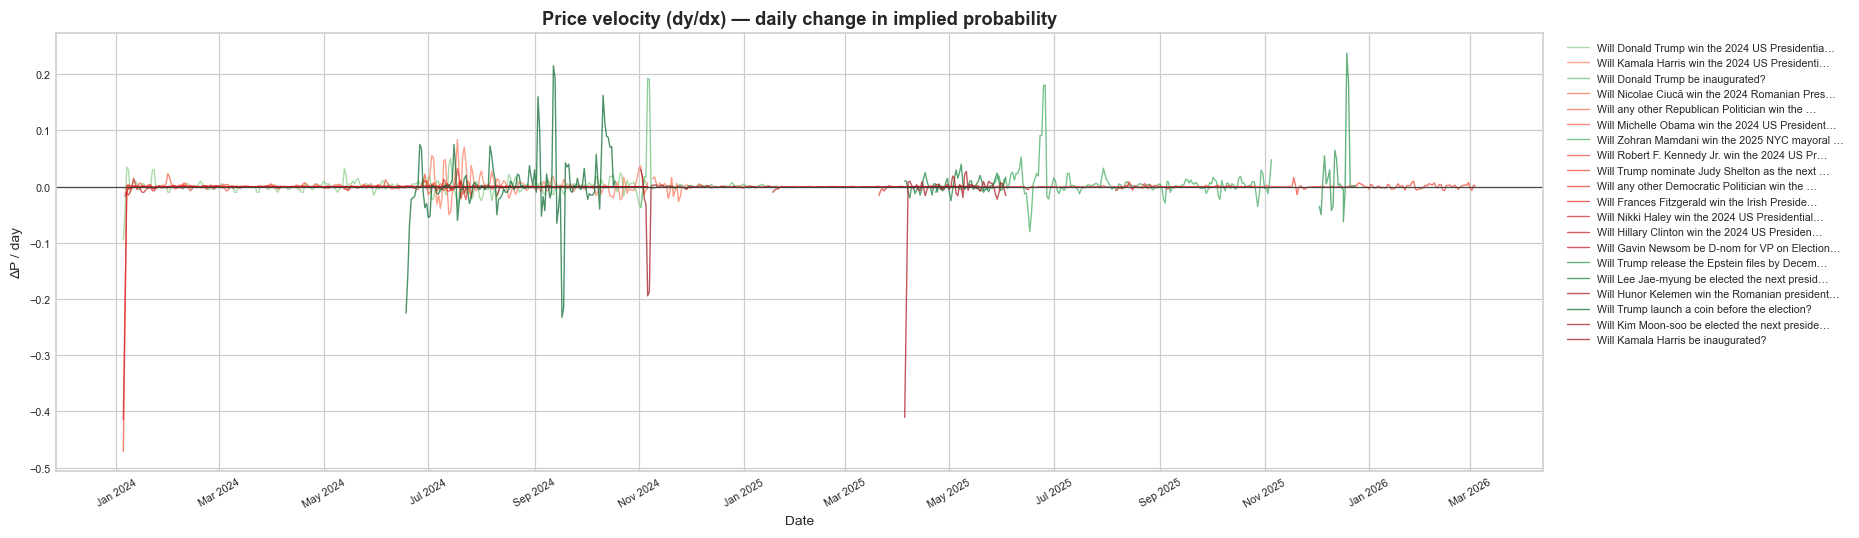

In [6]:
fig, ax = plt.subplots(figsize=(17, 5))
for row in markets.iter_rows(named=True):
    slug   = row['slug']
    df     = price_history.filter(pl.col('slug') == slug).sort('date')
    dates  = df['date'].to_list()
    prices = np.array(df['price'].to_list(), dtype=float)
    if len(prices) < 3: continue
    dydx  = np.gradient(prices)
    label = row['question'][:45] + '…' if len(row['question']) > 45 else row['question']
    ax.plot(dates, dydx, color=color_map[slug], linewidth=0.9, alpha=0.7, label=label)
ax.axhline(0, color='#444', linewidth=0.8)
ax.set_ylabel('ΔP / day')
ax.set_xlabel('Date')
ax.set_title('Price velocity (dy/dx) — daily change in implied probability', fontweight='bold', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1, framealpha=0.8)
plt.tight_layout()
plt.show()

## 4. Individual market panels
Price (solid fill) + dy/dx (dashed, right axis). Resolution top-right, volume bottom-left.

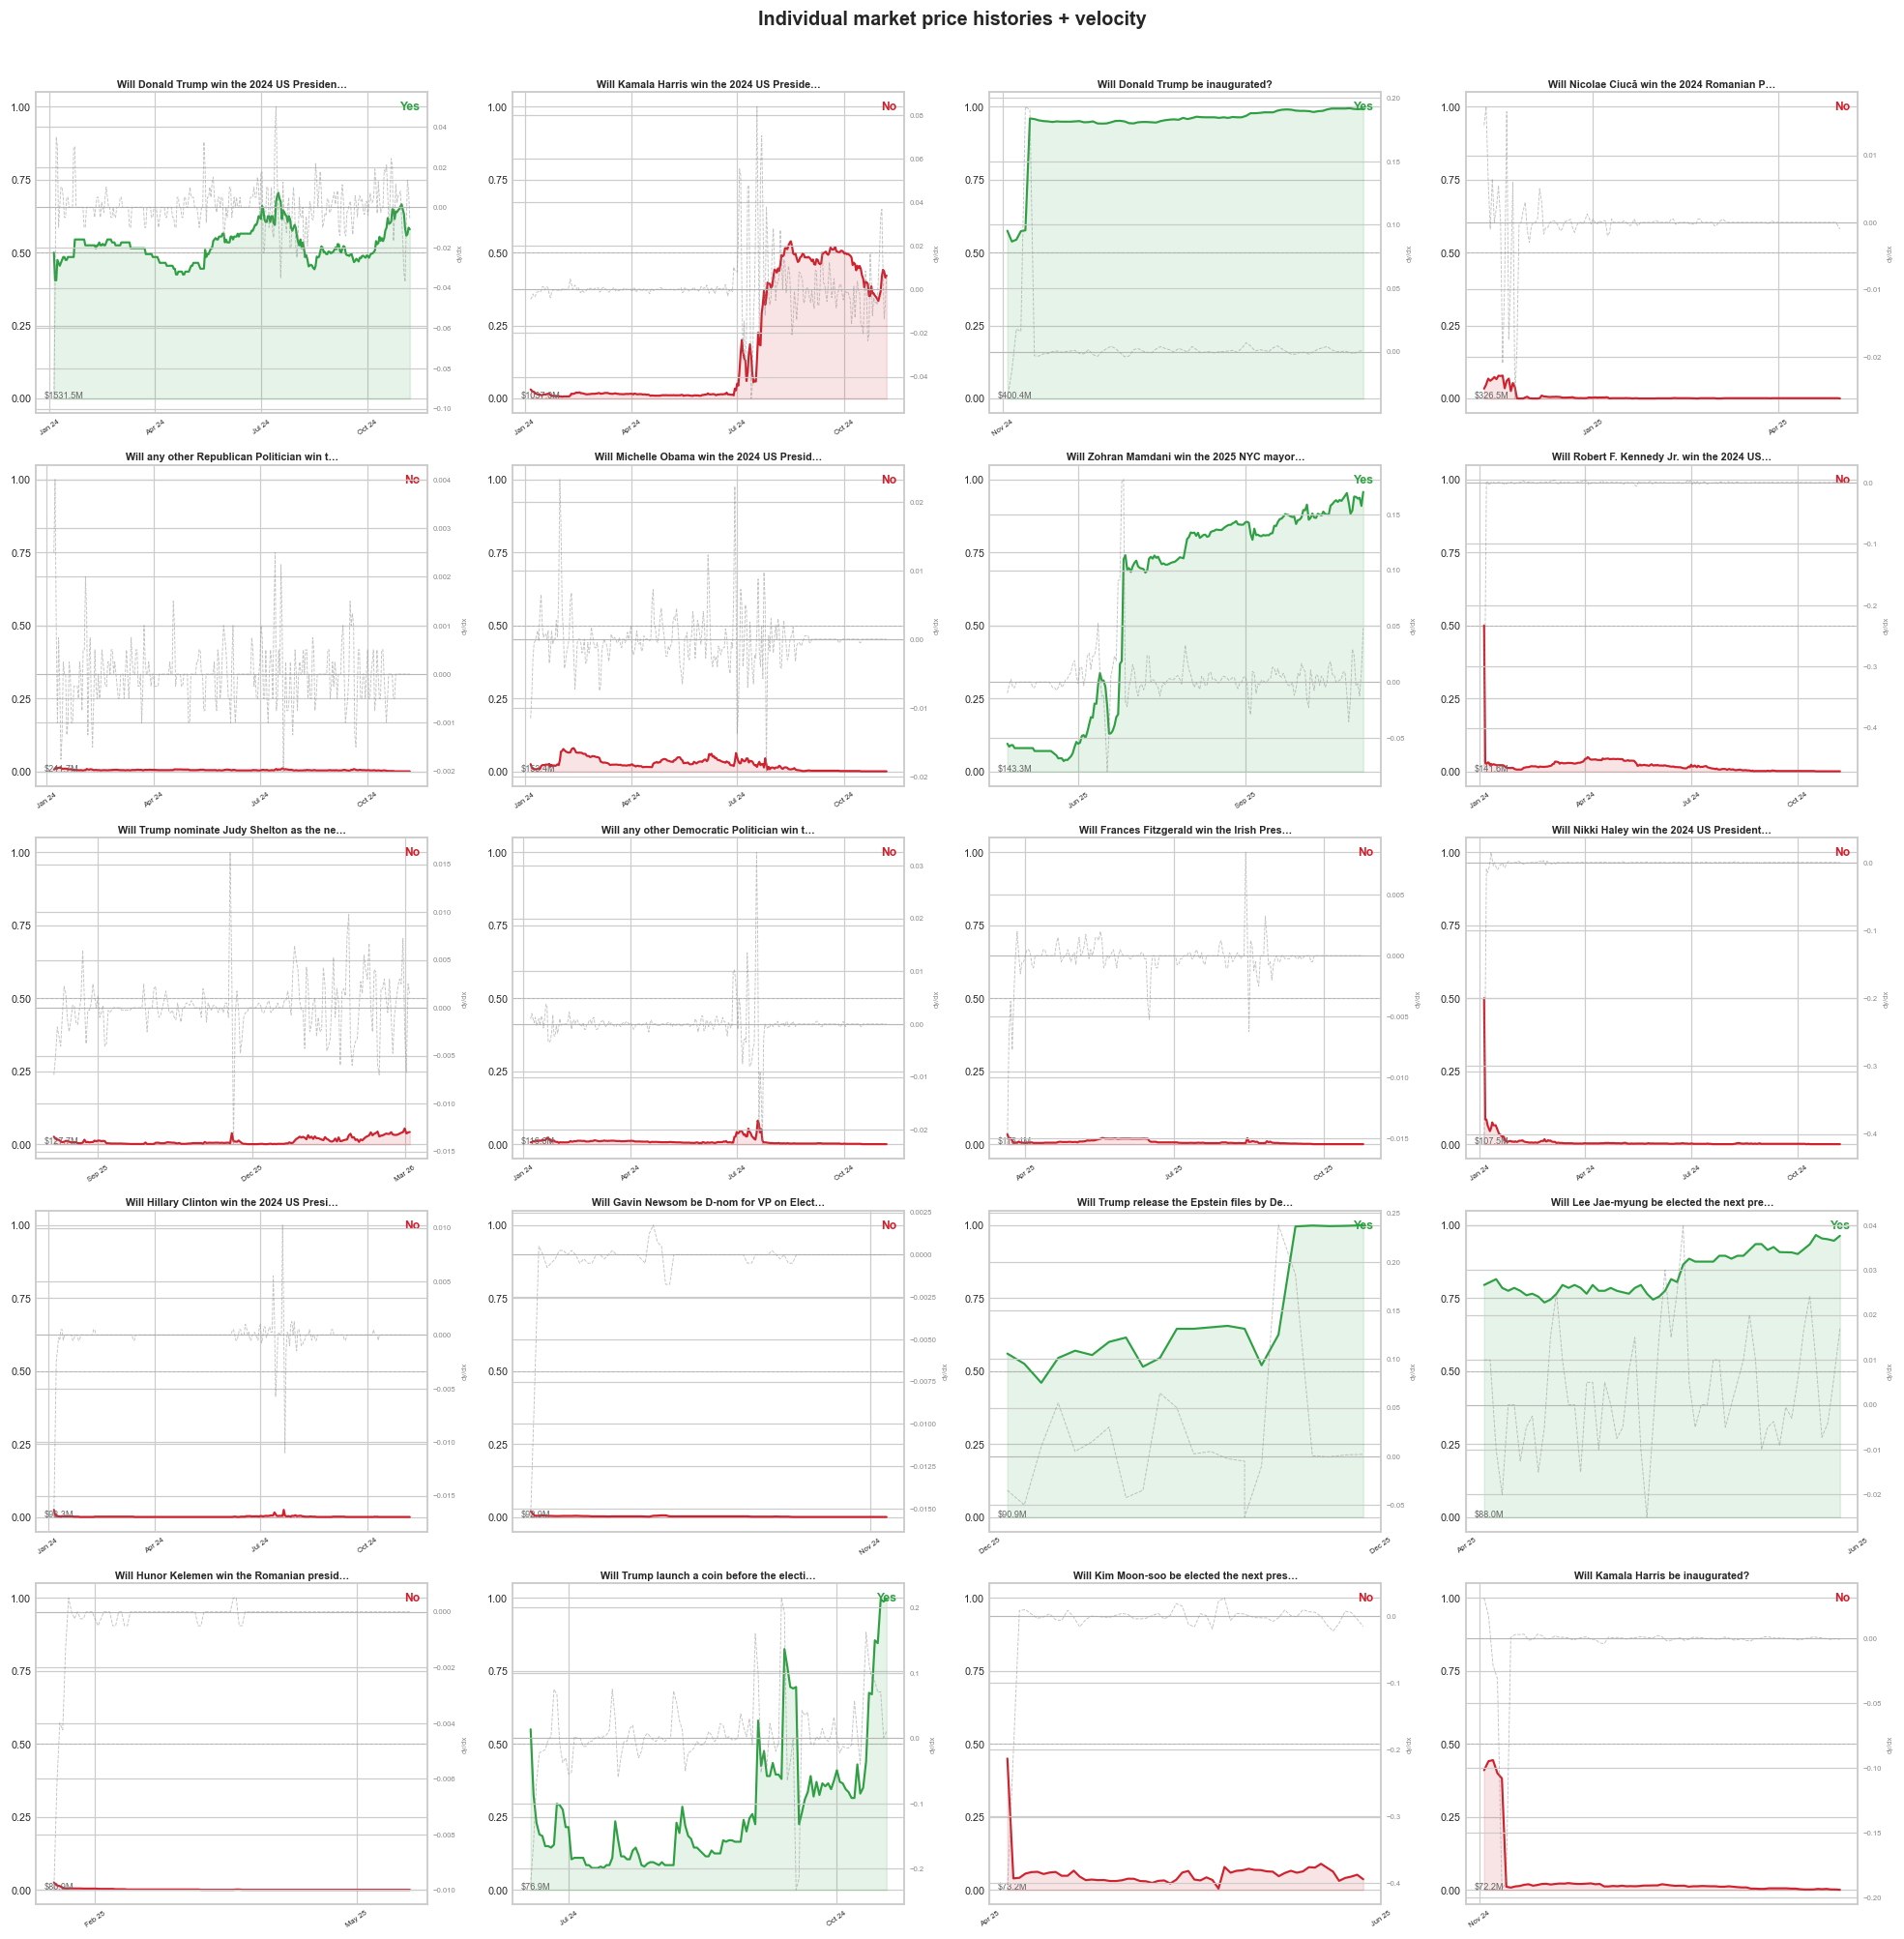

In [7]:
ncols = 4
nrows = -(-len(markets) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.6))
axes = axes.flatten()
for i, row in enumerate(markets.iter_rows(named=True)):
    ax     = axes[i]
    slug   = row['slug']
    df     = price_history.filter(pl.col('slug') == slug).sort('date')
    dates  = df['date'].to_list()
    prices = np.array(df['price'].to_list(), dtype=float)
    is_yes = (row['resolution'] == 'Yes')
    c_main = '#2ea043' if is_yes else '#cf222e'
    ax.plot(dates, prices, color=c_main, linewidth=1.4, zorder=3)
    ax.fill_between(dates, prices, alpha=0.12, color=c_main, zorder=2)
    ax.axhline(0.5, color='#aaa', linestyle='--', linewidth=0.6, alpha=0.7)
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
    if len(prices) >= 3:
        dydx = np.gradient(prices)
        ax2  = ax.twinx()
        ax2.plot(dates, dydx, color='#888', linewidth=0.6, alpha=0.5, linestyle='--')
        ax2.axhline(0, color='#aaa', linewidth=0.4)
        ax2.set_ylabel('dy/dx', fontsize=5, color='#888')
        ax2.tick_params(axis='y', labelsize=5, colors='#888')
    title = row['question']
    if len(title) > 42: title = title[:42] + '…'
    ax.set_title(title, fontsize=7, fontweight='bold', pad=3)
    ax.text(0.98, 0.97, row['resolution'], transform=ax.transAxes, ha='right', va='top', fontsize=8, fontweight='bold', color=c_main)
    vol = float(row['volume_usdc'] or 0)
    ax.text(0.02, 0.04, f'${vol/1e6:.1f}M', transform=ax.transAxes, ha='left', va='bottom', fontsize=6, color='#666')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, fontsize=5)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Individual market price histories + velocity', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Build `bet_history.csv`

In [8]:
bet_history = (
    trades_all
    .select(['market_slug','question','resolution','side',pl.col('price').cast(pl.Float64),pl.col('size').cast(pl.Float64),pl.col('timestamp').cast(pl.Int64),pl.col('date').alias('datetime'),'outcome','tx_hash'])
    .sort('timestamp')
)
bet_history.write_csv(EDA / 'bet_history.csv')
print(f'Saved bet_history.csv — {len(bet_history):,} rows')
bet_history.head(5)

Saved bet_history.csv — 40,000 rows


market_slug,question,resolution,side,price,size,timestamp,datetime,outcome,tx_hash
str,str,str,str,f64,f64,i64,datetime[μs],str,str
"""will-gavin-newsom-be-d-nom-for…","""Will Gavin Newsom be D-nom for…","""No""","""BUY""",0.999,14.18,1728035969,2024-10-04 09:59:29,"""No""","""0xff143743d7792ebf1295790c7731…"
"""will-gavin-newsom-be-d-nom-for…","""Will Gavin Newsom be D-nom for…","""No""","""BUY""",0.999,16.21,1728035971,2024-10-04 09:59:31,"""No""","""0x5e7b282f99b92f11abcd2bfabc77…"
"""will-gavin-newsom-be-d-nom-for…","""Will Gavin Newsom be D-nom for…","""No""","""BUY""",0.999,14.18,1728035977,2024-10-04 09:59:37,"""No""","""0x0f6a08cef917bc864d48e43a31ea…"
"""will-gavin-newsom-be-d-nom-for…","""Will Gavin Newsom be D-nom for…","""No""","""BUY""",0.999,12.16,1728035981,2024-10-04 09:59:41,"""No""","""0x2d33fca5844298424fe46f2a6f16…"
"""will-gavin-newsom-be-d-nom-for…","""Will Gavin Newsom be D-nom for…","""No""","""SELL""",0.001,91.21,1728035983,2024-10-04 09:59:43,"""Yes""","""0x7d0fecb1ca9adc35c7e7f224ff6f…"


## 6. Bet sizes across time

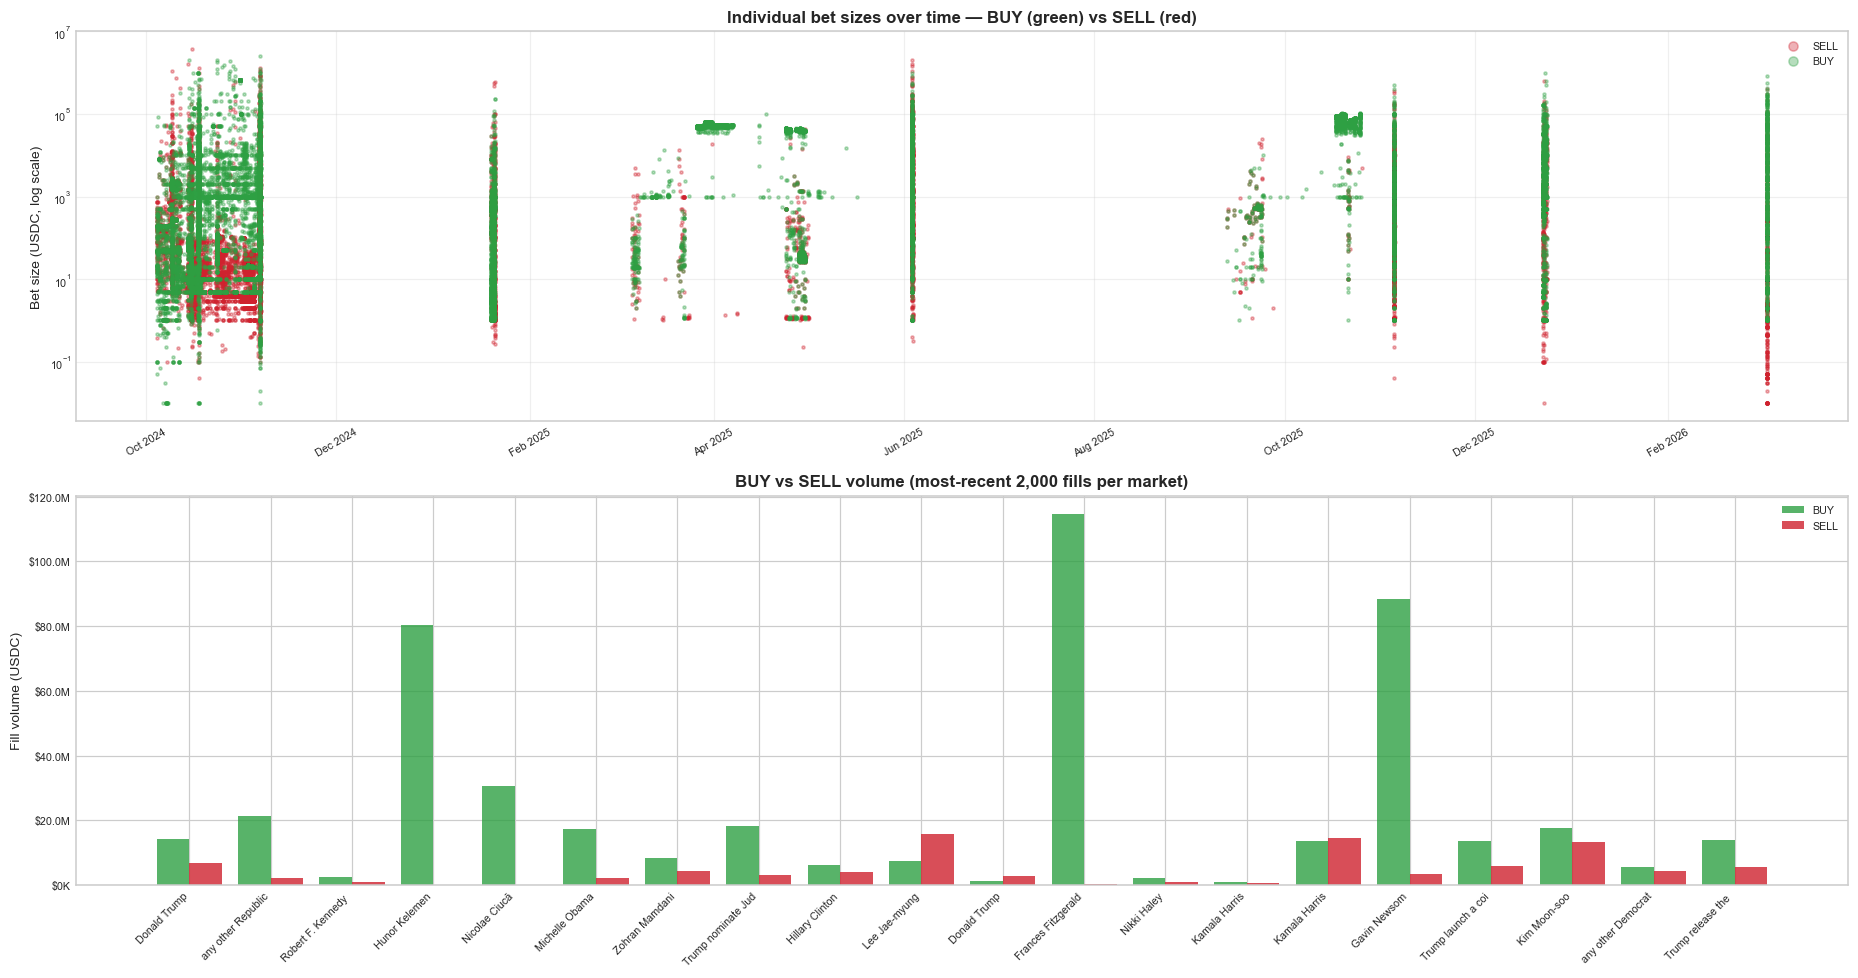

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(17, 9))
ax = axes[0]
for side, hex_col, z in [('SELL','#cf222e',2),('BUY','#2ea043',3)]:
    sub = trades_all.filter(pl.col('side') == side)
    ax.scatter(sub['date'].to_list(), sub['size'].to_list(), s=4, alpha=0.35, color=hex_col, label=side, zorder=z)
ax.set_yscale('log')
ax.set_ylabel('Bet size (USDC, log scale)')
ax.set_title('Individual bet sizes over time — BUY (green) vs SELL (red)', fontweight='bold', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.legend(markerscale=3, framealpha=0.8)
ax.grid(True, which='both', alpha=0.3)
ax2 = axes[1]
vol_by_market = (trades_all.group_by(['market_slug','side']).agg(pl.col('size').sum().alias('total')).pivot(on='side',index='market_slug',values='total').fill_null(0))
slugs  = vol_by_market['market_slug'].to_list()
labels = [slug_to_short.get(s, s[:15]) for s in slugs]
x, w   = np.arange(len(slugs)), 0.4
if 'BUY'  in vol_by_market.columns: ax2.bar(x - w/2, vol_by_market['BUY'].to_list(),  w, label='BUY',  color='#2ea043', alpha=0.8)
if 'SELL' in vol_by_market.columns: ax2.bar(x + w/2, vol_by_market['SELL'].to_list(), w, label='SELL', color='#cf222e', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax2.set_ylabel('Fill volume (USDC)')
ax2.set_title('BUY vs SELL volume (most-recent 2,000 fills per market)', fontweight='bold', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e3:.0f}K' if v < 1e6 else f'${v/1e6:.1f}M'))
ax2.legend(framealpha=0.8)
plt.tight_layout()
plt.show()

## 7. Bet size distribution

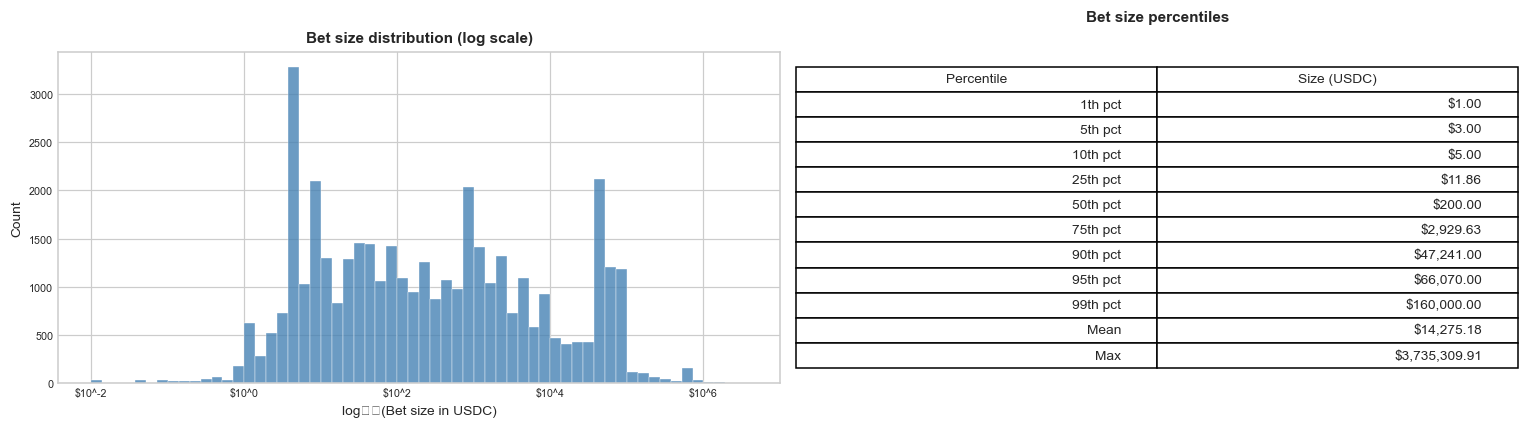

In [10]:
sizes = np.array(trades_all['size'].drop_nulls().to_list(), dtype=float)
sizes = sizes[sizes > 0]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.hist(np.log10(sizes), bins=60, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.set_xlabel('log₁₀(Bet size in USDC)')
ax.set_ylabel('Count')
ax.set_title('Bet size distribution (log scale)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'$10^{int(round(v))}'))
ax2 = axes[1]
ax2.axis('off')
pcts = [1,5,10,25,50,75,90,95,99]
vals = np.percentile(sizes, pcts)
tbl_data = [[f'{p}th pct', f'${v:,.2f}'] for p, v in zip(pcts, vals)]
tbl_data += [['Mean', f'${sizes.mean():,.2f}'],['Max', f'${sizes.max():,.2f}']]
tbl = ax2.table(cellText=tbl_data, colLabels=['Percentile','Size (USDC)'], loc='center', cellLoc='right')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)
ax2.set_title('Bet size percentiles', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 8. Cumulative order flow — top 6 markets

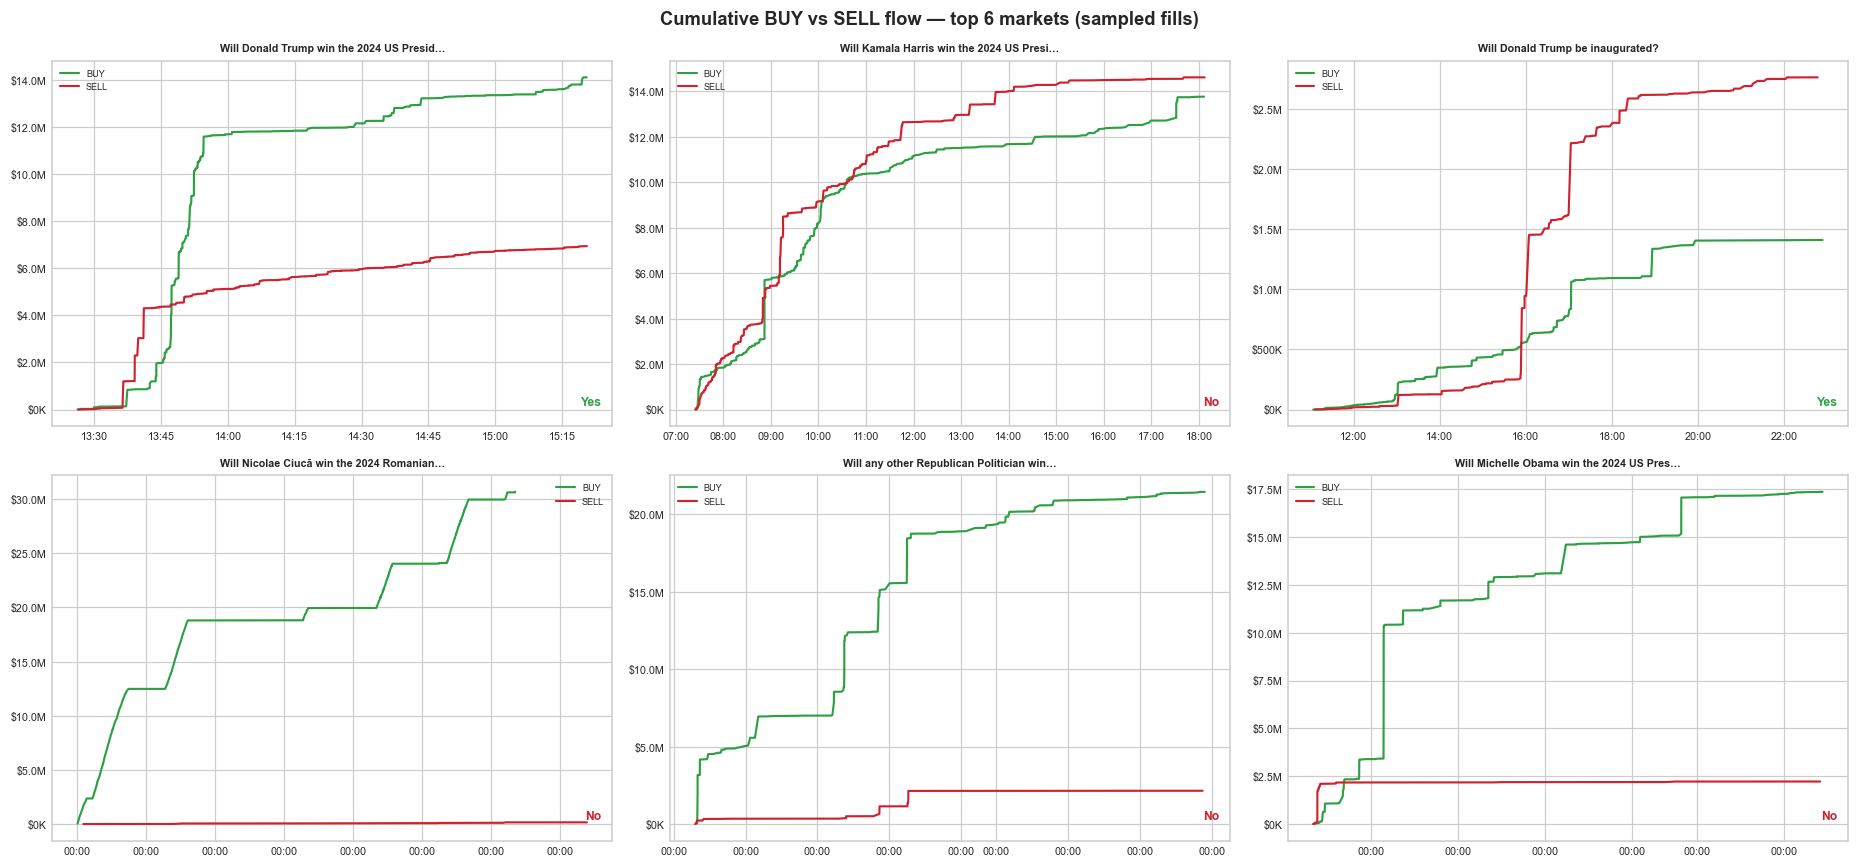

In [11]:
top6 = markets.sort('volume_usdc', descending=True).head(6)['slug'].to_list()
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes = axes.flatten()
fmt_usdc = mticker.FuncFormatter(lambda v, _: f'${v/1e3:.0f}K' if v < 1e6 else f'${v/1e6:.1f}M')
for i, slug in enumerate(top6):
    ax  = axes[i]
    row = markets.filter(pl.col('slug') == slug).row(0, named=True)
    df  = trades_all.filter(pl.col('market_slug') == slug).sort('date')
    if df.is_empty():
        ax.set_visible(False)
        continue
    for side, hex_col in [('BUY','#2ea043'),('SELL','#cf222e')]:
        sub = df.filter(pl.col('side') == side)
        if not sub.is_empty():
            ax.plot(sub['date'].to_list(), np.cumsum(sub['size'].to_list()), color=hex_col, linewidth=1.4, label=side)
    is_yes = (row['resolution'] == 'Yes')
    c = '#2ea043' if is_yes else '#cf222e'
    title = row['question'][:40] + '…' if len(row['question']) > 40 else row['question']
    ax.set_title(title, fontsize=7, fontweight='bold')
    ax.text(0.98, 0.05, row['resolution'], transform=ax.transAxes, ha='right', va='bottom', fontsize=8, fontweight='bold', color=c)
    ax.yaxis.set_major_formatter(fmt_usdc)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.legend(fontsize=6)
fig.suptitle('Cumulative BUY vs SELL flow — top 6 markets (sampled fills)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Summary statistics

In [12]:
summary = (
    price_history.group_by('slug')
    .agg([pl.col('price').first().alias('open'),pl.col('price').last().alias('close'),pl.col('price').max().alias('high'),pl.col('price').min().alias('low'),pl.col('price').std().alias('daily_std'),pl.col('date').count().alias('n_candles')])
    .join(markets.select(['slug','resolution','volume_usdc']), on='slug')
    .with_columns([(pl.col('close') - pl.col('open')).alias('drift'),(pl.col('daily_std') * float(252**0.5)).alias('ann_vol')])
    .sort('volume_usdc', descending=True)
)
summary.select(['slug','resolution','open','close','drift','high','low','ann_vol','n_candles','volume_usdc'])

slug,resolution,open,close,drift,high,low,ann_vol,n_candles,volume_usdc
str,str,f64,f64,f64,f64,f64,f64,u32,f64
"""will-donald-trump-win-the-2024…","""Yes""",0.5,0.58,0.08,0.705,0.405,0.932847,307,1.5315e9
"""will-kamala-harris-win-the-202…","""No""",0.0315,0.4215,0.39,0.539,0.0065,3.323036,306,1.0370e9
"""will-donald-trump-be-inaugurat…","""Yes""",0.575,0.9925,0.4175,0.9945,0.538,1.584668,80,4.0041e8
"""will-nicolae-ciuca-win-the-202…","""No""",0.034,0.0005,-0.0335,0.079,0.0005,0.27367,174,3.2651e8
"""will-any-other-republican-poli…","""No""",0.0065,0.0005,-0.006,0.0145,0.0005,0.031519,305,2.4166e8
…,…,…,…,…,…,…,…,…,…
"""will-lee-jae-myung-be-elected-…","""Yes""",0.795,0.9635,0.1685,0.966,0.735,1.128741,60,8.8036e7
"""romania-presidential-election-…","""No""",0.0255,0.0005,-0.025,0.0255,0.0005,0.048889,122,8.0897e7
"""will-trump-launch-a-coin-befor…","""Yes""",0.55,0.9975,0.4475,0.9975,0.075,3.410548,123,7.6899e7


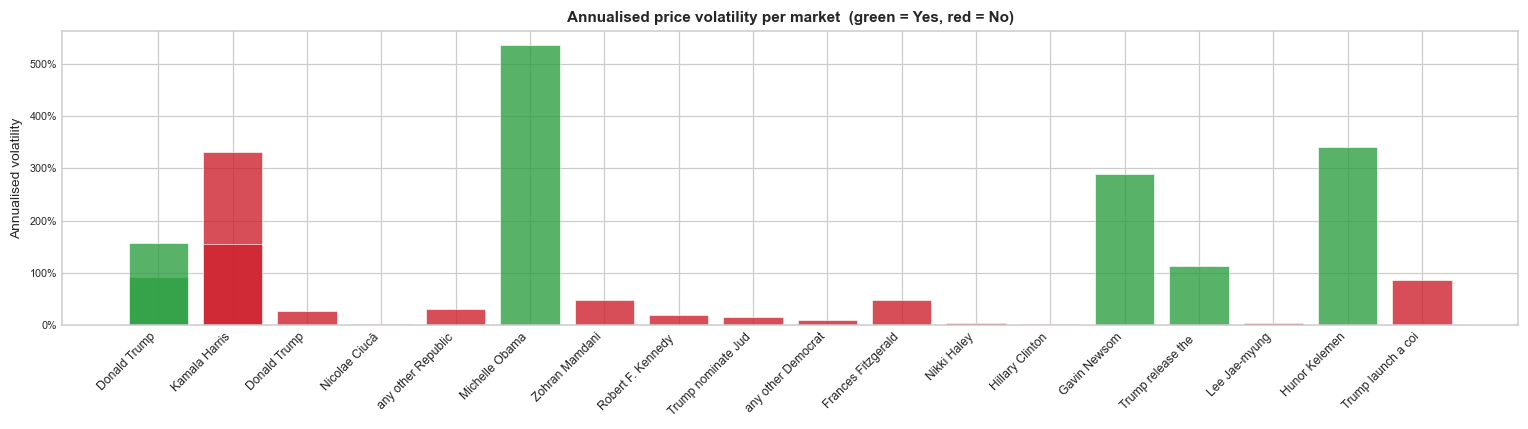

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
slugs  = summary['slug'].to_list()
labels = [slug_to_short.get(s, s[:15]) for s in slugs]
vols   = [float(v) for v in summary['ann_vol'].to_list()]
colors = ['#2ea043' if r == 'Yes' else '#cf222e' for r in summary['resolution'].to_list()]
ax.bar(labels, vols, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Annualised volatility')
ax.set_title('Annualised price volatility per market  (green = Yes, red = No)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

---
**Files in `EDA/`:**  
`bet_history.csv` — 40,000 fills with market context  
`markets.csv` — metadata + resolution  
`{slug}/price_history.csv` — daily YES candles  
`{slug}/trades.csv` — 2,000 most-recent fills per market